# Detecção de Pontos de Mudanças em Imagens SAR baseada em redes ConvLSTM

O presente notebook detalha um experimento no treinamento de redes ConvLSTM e ConvGRU para detecção de mudanças em dados de imagens SAR, com o estudo de caso em áreas do arco do desmatamento na Amazônia, como parte de um projeto final da disciplina de Aprendizado Profundo do INPE (CAP 421).

Discente: João Pedro Melani Saraiva

## Treinamento

Esta seção lida com a etapa de treinamento de todas as arquiteturas experimentadas.

In [35]:
from src.data import DataPipeline # Módulo para baixar e pré-processar os dados
from src.train import conv_rnn_training # Módulo para treinar modelos ConvRNN
from src.dataset import SARDataset # Módulo para criar datasets a partir dos dados pré-processados
from src.models import ConvGRURegressor, ConvLSTMRegressor # Módulo para definir modelos ConvRNN
from src.inference import load_weights, conv_rnn_predict, masked_mae, masked_rmse # Módulo para fazer inferência
from src.utils import load_history # Módulo com utilitários gerais
import torch
import rasterio as rio
from rasterio.enums import Resampling
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import numpy as np
import pandas as pd
import logging
from pathlib import Path
import shutil
import re

In [36]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger(__name__)

Declaração de variáveis do ambiente:

In [ ]:
# Diretórios e caminhos de arquivos
DATA_DIR = "data/preprocessed"
LABEL_PATH = "data/labels/sample_2018_2024_normalized.tif"
STATS_PATH = "data/aggregated/norm_stats.json"

# Diretórios e caminhos de arquivos para teste
TEST_DATA_DIR = "data/preprocessed_test"
TEST_LABEL_PATH = "data/labels/test_2018_2024_normalized.tif"
TEST_STATS_PATH = "data/aggregated/norm_stats_test.json"

# Diretórios para salvar pesos, logs e resultados
WEIGHTS_DIR = Path("checkpoints")
LOGS_DIR = Path("logs")
RESULTS_DIR = Path("results")

# Tamanho do patch e tamanho do batch
PATCH_SIZE = 128
BATCH_SIZE = 2

# Hiperparâmetros para grid search
ARCH = ["ConvGRU", "ConvLSTM"]
HIDDEN_CHANNELS = [16, 32]
LEARNING_RATE = [1e-3, 5e-4]
KERNEL_SIZE = [3, 5]

# Épocas de treinamento
EPOCHS = 50

# Constantes
YEAR_START = 2018
YEAR_END = 2024
HEAD_CHANNELS = [16]
VAL_FRACTION = 0.2
POS_WEIGHT = 3.26 # Peso da classe 'não mudança' na função de perda (para lidar com desbalanceamento de classes)
INPUT_CHANNELS = 2
SEED = 0

Função para puxar e pré-processar dados. Basta passar `False` para os argumentos `skip_raw` e `skip_preproc` que a função irá automaticamente buscar os dados do Kaggle e pré-processar eles. Os rótulos já estão salvos no repositório. A busca de dados brutos pode ser ignorada se os dados já estiverem presentes parssando `True`:

In [38]:
def fetch_train_data(skip_raw=True, skip_preproc=True):
    # Engenharia de dados: baixar, pré-processar e normalizar os dados
    pipeline = DataPipeline(
        label_path="data/labels/sample_2000_2024.tif",
        raw_path="data/raw/",
        preproc_path="data/preprocessed/",
        stats_path=STATS_PATH,
        year_start=YEAR_START,
        year_end=YEAR_END
    )
    if not skip_raw:
        pipeline.raw()
    if not skip_preproc:
        pipeline.preprocessed()
        pipeline.labels(outfile=f"data/labels/sample_{YEAR_START}_{YEAR_END}_normalized.tif")
        
fetch_train_data()

*Grid search* sobre os hiper-parâmetros declarados, totalizando 16 combinações em 50 épocas (~16h de treinamento em uma T4 Kaggle). Como os pesos estão salvos em `checkpoints/`, o processo de treinamento é pulado:

In [40]:
def train():
    
    # Loop de treinamento para cada combinação de hiperparâmetros
    logger.info("Procedimento de treinamento iniciado.")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        logger.info(f"Device: {torch.cuda.get_device_name(0)}")
        
    dataset = SARDataset(
        data_dir=DATA_DIR, 
        label_path=LABEL_PATH,
        stats_path=STATS_PATH,
        patch_size=PATCH_SIZE
    )

    n_val = max(1, int(len(dataset) * VAL_FRACTION))
    n_train = len(dataset) - n_val
    generator = torch.Generator().manual_seed(SEED)
    train_set, val_set = random_split(dataset, [n_train, n_val], generator=generator)
       
    WEIGHTS_DIR.mkdir(exist_ok=True)
    LOGS_DIR.mkdir(exist_ok=True)

    for arch in ARCH:
        for hidden in HIDDEN_CHANNELS:
            for kernel in KERNEL_SIZE:
                for lr in LEARNING_RATE:
                    weights_str = f"{arch}_" + f"hidden{hidden}-" + f"kernel{kernel}-" + f"lr{lr}".replace(".", "p")
                    weights_path = WEIGHTS_DIR / f"{weights_str}.pth"
                    history_path = LOGS_DIR / f"{weights_str}.parquet"
                    
                    if weights_path.exists():
                        logger.warning(f"Checkpoint de {weights_str} já existe. Pulando...")
                        continue
                    
                    logger.info(f"Começando arquitetura {weights_str}")
                    
                    history = conv_rnn_training(
                        input_channels=INPUT_CHANNELS,
                        kernel_size=kernel,
                        hidden_channels=hidden,
                        head_channels=HEAD_CHANNELS,
                        lrate=lr,
                        train_dataset=train_set,
                        val_dataset=val_set,
                        batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        pos_weight=POS_WEIGHT,
                        device=device,
                        weights_path=weights_path,
                        arch=arch,
                        patience=None
                    )
                    
                    history.to_parquet(history_path, index=False)
                
train()

2026-09-02 19:11:36,475 | INFO | __main__ | Procedimento de treinamento iniciado.
2026-09-02 19:11:36,476 | INFO | __main__ | Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU
2026-09-02 19:11:36,480 | WARNING | __main__ | Checkpoint de ConvGRU_hidden16-kernel3-lr0p001 já existe. Pulando...
2026-09-02 19:11:36,482 | WARNING | __main__ | Checkpoint de ConvGRU_hidden16-kernel3-lr0p0005 já existe. Pulando...
2026-09-02 19:11:36,483 | WARNING | __main__ | Checkpoint de ConvGRU_hidden16-kernel5-lr0p001 já existe. Pulando...
2026-09-02 19:11:36,484 | WARNING | __main__ | Checkpoint de ConvGRU_hidden16-kernel5-lr0p0005 já existe. Pulando...
2026-09-02 19:11:36,487 | WARNING | __main__ | Checkpoint de ConvGRU_hidden32-kernel3-lr0p001 já existe. Pulando...
2026-09-02 19:11:36,489 | WARNING | __main__ | Checkpoint de ConvGRU_hidden32-kernel3-lr0p0005 já existe. Pulando...
2026-09-02 19:11:36,491 | WARNING | __main__ | Checkpoint de ConvGRU_hidden32-kernel5-lr0p001 já existe. Pulando...
2026-09-02 1

## Avaliação e Teste

Esta seção lida com a avaliação e teste dos modelos treinados. De forma análoga à função `fetch_train_data()`, a função a seguir serve para puxar e pré-processar dados de teste. Novamente, a busca de dados pode ser ignorada se dados já estão presentes:

In [41]:
def fetch_test_data(skip_raw=True, skip_preproc=True):

    pipeline = DataPipeline(
        label_path="data/labels/test_2000_2024.tif",
        raw_path="data/raw_test/",
        preproc_path="data/preprocessed_test/",
        stats_path=TEST_STATS_PATH,
        year_start=YEAR_START,
        year_end=YEAR_END
    )
    if not skip_raw:
        pipeline.raw()
    if not skip_preproc:
        pipeline.preprocessed()
        pipeline.labels(outfile=f"data/labels/test_{YEAR_START}_{YEAR_END}_normalized.tif")
        
fetch_test_data()

Esta função auxilia a avaliar métricas de erros para cada arquitetura:

In [42]:
def evaluate(
    weights: list[str | Path],
    dataset: SARDataset,
    results_dir: str | Path
) -> list[dict]:
    
    results = []
    pattern = r"(?P<model>[^_]+)_hidden(?P<hidden>\d+)-kernel(?P<kernel>\d+)-lr(?P<lr>[\d]+p[\d]+)"
    
    results_dir = Path(results_dir)
    results_dir.mkdir(exist_ok=True)
    
    with rio.open(dataset.label_path) as src:
        labels = src.read(1)
        profile = src.profile.copy()
    
    profile.update(count=1, dtype="float32", compress="lzw")
    
    logger.info(f"Avaliando {len(weights)} checkpoints em {len(dataset)} amostras...")
    for w in weights:
        
        array_path = results_dir / f"{w.stem}.tif"
        metrics_path = results_dir / f"{w.stem}.parquet"
        
        if array_path.exists() and metrics_path.exists():
            logger.warning(f"Resultados para {w.stem} já existem. Pulando...")
            results.append(pd.read_parquet(metrics_path).iloc[0].to_dict())
            continue
        
        match = re.fullmatch(pattern, w.stem)
        params = match.groupdict()
        
        if params["model"] == "ConvGRU":
            arch = ConvGRURegressor
        elif params["model"] == "ConvLSTM":
            arch = ConvLSTMRegressor
        else:
            raise ValueError("Arquitetura desconhecida...")
            
        model = load_weights(
            arch, w,
            input_channels=INPUT_CHANNELS,
            hidden_channels=int(params["hidden"]),
            kernel_size=int(params["kernel"]),
            head_channels=HEAD_CHANNELS
        )
        
        result = conv_rnn_predict(
            model=model,
            dataset=dataset,
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            batch_size=BATCH_SIZE
        )
        
        with rio.open(array_path, "w", **profile) as dst:
            dst.write(result.astype("float32"), 1)
        
        metrics = {
            "model": params["model"],
            "hidden": int(params["hidden"]),
            "kernel": int(params["kernel"]),
            "lr": float(params["lr"].replace("p", ".")),
            "array_path": str(array_path),
            "rmse": masked_rmse(result, labels),
            "mae": masked_mae(result, labels)
        }
        
        pd.DataFrame([metrics]).to_parquet(metrics_path, index=False)
        
        results.append(metrics)
        logger.info(f"Avaliando {w.stem}: RMSE={metrics['rmse']:.5f}, MAE={metrics['mae']:.5f}")
    
    return results

Rodando avaliação para os dados originais (apenas para ilustração):

In [44]:
weight_list = sorted(list(WEIGHTS_DIR.iterdir()))
VAL_RESULTS_DIR = RESULTS_DIR / "validation"
VAL_RESULTS_DIR.parent.mkdir(exist_ok=True)

val_dataset = SARDataset(
    data_dir=DATA_DIR, 
    label_path=LABEL_PATH,
    stats_path=STATS_PATH,
    patch_size=PATCH_SIZE
)

val_results = evaluate(
    weight_list, 
    val_dataset,
    VAL_RESULTS_DIR
)

/tmp/ipykernel_99374/380491408.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  labels = src.read(1)
2026-09-02 19:14:31,925 | INFO | __main__ | Avaliando 16 checkpoints em 182 amostras...
2026-09-02 19:14:31,925 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel3-lr0p0005 já existem. Pulando...
2026-09-02 19:14:31,929 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel3-lr0p001 já existem. Pulando...
2026-09-02 19:14:31,933 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel5-lr0p0005 já existem. Pulando...
2026-09-02 19:14:31,937 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel5-lr0p001 já existem. Pulando...
2026-09-02 19:14:31,942 | WARNING | __main__ | Resultados para ConvGRU_hidden32-kernel3-lr0p0005 já existem. Pulando...
2026-09-02 19:14:31,946 | WARNING | __main__ | Resultados para ConvGRU_hi

2026-09-02 19:14:31,960 | WARNING | __main__ | Resultados para ConvLSTM_hidden16-kernel3-lr0p0005 já existem. Pulando...
2026-09-02 19:14:31,964 | WARNING | __main__ | Resultados para ConvLSTM_hidden16-kernel3-lr0p001 já existem. Pulando...
2026-09-02 19:14:31,968 | WARNING | __main__ | Resultados para ConvLSTM_hidden16-kernel5-lr0p0005 já existem. Pulando...
2026-09-02 19:14:31,973 | WARNING | __main__ | Resultados para ConvLSTM_hidden16-kernel5-lr0p001 já existem. Pulando...
2026-09-02 19:14:31,978 | WARNING | __main__ | Resultados para ConvLSTM_hidden32-kernel3-lr0p0005 já existem. Pulando...
2026-09-02 19:14:31,982 | WARNING | __main__ | Resultados para ConvLSTM_hidden32-kernel3-lr0p001 já existem. Pulando...
2026-09-02 19:14:31,987 | WARNING | __main__ | Resultados para ConvLSTM_hidden32-kernel5-lr0p0005 já existem. Pulando...
2026-09-02 19:14:31,992 | WARNING | __main__ | Resultados para ConvLSTM_hidden32-kernel5-lr0p001 já existem. Pulando...


Rodando avaliação para os dados de teste:

In [45]:
weight_list = sorted(list(WEIGHTS_DIR.iterdir()))
TEST_RESULTS_DIR = RESULTS_DIR / "test"
TEST_RESULTS_DIR.parent.mkdir(exist_ok=True)

test_dataset = SARDataset(
    data_dir=TEST_DATA_DIR, 
    label_path=TEST_LABEL_PATH,
    stats_path=TEST_STATS_PATH,
    patch_size=PATCH_SIZE
)

test_results = evaluate(
    weight_list, 
    test_dataset,
    TEST_RESULTS_DIR
)

/tmp/ipykernel_99374/380491408.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  labels = src.read(1)
2026-09-02 19:14:40,387 | INFO | __main__ | Avaliando 16 checkpoints em 182 amostras...
2026-09-02 19:14:40,388 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel3-lr0p0005 já existem. Pulando...
2026-09-02 19:14:40,395 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel3-lr0p001 já existem. Pulando...


2026-09-02 19:14:40,398 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel5-lr0p0005 já existem. Pulando...
2026-09-02 19:14:40,403 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel5-lr0p001 já existem. Pulando...
2026-09-02 19:14:40,407 | WARNING | __main__ | Resultados para ConvGRU_hidden32-kernel3-lr0p0005 já existem. Pulando...
2026-09-02 19:14:40,415 | WARNING | __main__ | Resultados para ConvGRU_hidden32-kernel3-lr0p001 já existem. Pulando...
2026-09-02 19:14:40,421 | WARNING | __main__ | Resultados para ConvGRU_hidden32-kernel5-lr0p0005 já existem. Pulando...
2026-09-02 19:14:40,428 | WARNING | __main__ | Resultados para ConvGRU_hidden32-kernel5-lr0p001 já existem. Pulando...
2026-09-02 19:14:40,435 | WARNING | __main__ | Resultados para ConvLSTM_hidden16-kernel3-lr0p0005 já existem. Pulando...
2026-09-02 19:14:40,444 | WARNING | __main__ | Resultados para ConvLSTM_hidden16-kernel3-lr0p001 já existem. Pulando...
2026-09-02 19:14:40,451 | WARNING | __main

Encontra-se o melhor modelo (menor MAE na área de teste) e salva seus pesos na raiz do projeto:

In [46]:
test_files = sorted(TEST_RESULTS_DIR.glob("*.parquet"))
test_summary = pd.concat([pd.read_parquet(f) for f in test_files], ignore_index=True)

best_metrics = test_summary.loc[test_summary["mae"].idxmin()]
best_run = (
    f"{best_metrics['model']}_hidden{int(best_metrics['hidden'])}"
    f"-kernel{int(best_metrics['kernel'])}-lr{best_metrics['lr']}"
).replace(".", "p")

best_weights_path = WEIGHTS_DIR / f"{best_run}.pth"
best_model_path = Path("best_model.pth")
shutil.copy2(best_weights_path, best_model_path)

logger.info(
    f"Melhor modelo: {best_run} (RMSE={best_metrics['rmse']:.5f}, MAE={best_metrics['mae']:.5f}) "
    f"salvo em {best_model_path}"
)

2026-09-02 19:14:55,779 | INFO | __main__ | Melhor modelo: ConvGRU_hidden16-kernel5-lr0p001 (RMSE=0.23627, MAE=0.09639) salvo em best_model.pth


## Análise e Visualização

A presente seção contribui como análise exploratória e visualização dos resultados do modelo. O gráfico a seguir demonstra as séries temporais médias de VV/VH (normalizadas por imagem), agrupadas por valor de rótulo. Cada grupo representa uma classe de recência de mudança, do mais antigo (0) ao mais recente (1):

/tmp/ipykernel_99374/2977617314.py:12: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  rio.open(data_dir / f"{month}.VH.tif").read(1),
/tmp/ipykernel_99374/2977617314.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  rio.open(data_dir / f"{month}.VV.tif").read(1),
/tmp/ipykernel_99374/2977617314.py:19: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  labels = src.read(1)


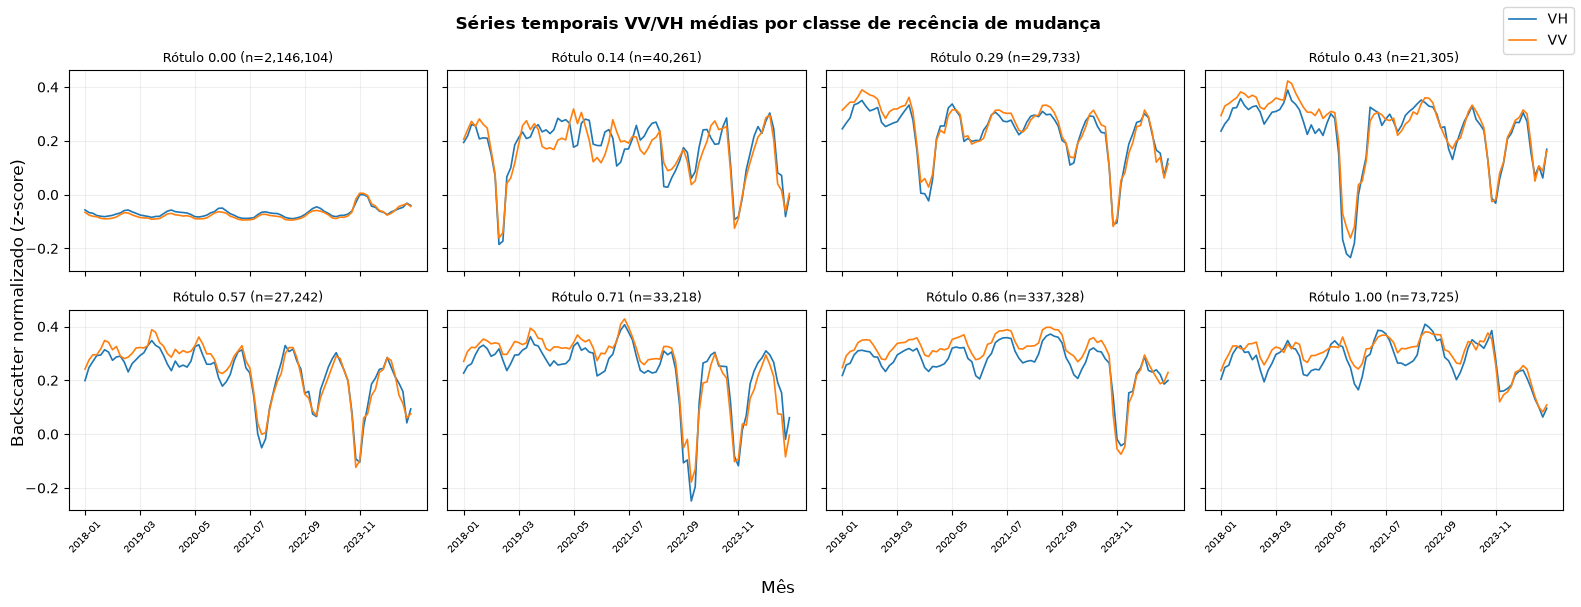

In [47]:
def plot_label_timeseries(ncols=4):
    
    data_dir = Path(DATA_DIR)
    
    months = sorted({
        f.stem.split(".")[0]
        for f in data_dir.glob("*.tif")
    })
    
    stack = np.stack([
        np.stack([
            rio.open(data_dir / f"{month}.VH.tif").read(1),
            rio.open(data_dir / f"{month}.VV.tif").read(1),
        ], axis=0)
        for month in months
    ], axis=0)
    
    with rio.open(LABEL_PATH) as src:
        labels = src.read(1)
    
    # Normalização por imagem: cada mês é padronizado usando sua própria
    # média/desvio, para que a série temporal não seja dominada por
    # diferenças de escala entre meses
    vh_stack, vv_stack = stack[:, 0], stack[:, 1]
    
    vh_norm = (
        (vh_stack - vh_stack.mean(axis=(1, 2), keepdims=True))
        / (vh_stack.std(axis=(1, 2), keepdims=True) + 1e-6)
    ).astype(np.float32)
    
    vv_norm = (
        (vv_stack - vv_stack.mean(axis=(1, 2), keepdims=True))
        / (vv_stack.std(axis=(1, 2), keepdims=True) + 1e-6)
    ).astype(np.float32)
    
    unique_labels = np.unique(labels)
    
    nrows = -(-len(unique_labels) // ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_1d(axes).ravel()
    
    tick_step = max(1, len(months) // 6)
    tick_idx = list(range(0, len(months), tick_step))
    
    for ax, label in zip(axes, unique_labels):
        mask = labels == label
        n_pixels = int(mask.sum())
        
        vh_mean_ts = vh_norm[:, mask].mean(axis=1)
        vv_mean_ts = vv_norm[:, mask].mean(axis=1)
        
        ax.plot(vh_mean_ts, label="VH", linewidth=1.2)
        ax.plot(vv_mean_ts, label="VV", linewidth=1.2)
        
        ax.set_title(f"Rótulo {label:.2f} (n={n_pixels:,})", fontsize=9)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([months[i] for i in tick_idx], rotation=45, fontsize=7)
        ax.grid(alpha=0.2)
    
    for ax in axes[len(unique_labels):]:
        ax.axis("off")
    
    fig.supxlabel("Mês")
    fig.supylabel("Backscatter normalizado (z-score)")
    
    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_legend, loc="upper right")
    
    fig.suptitle(
        "Séries temporais VV/VH médias por classe de recência de mudança",
        fontweight="bold"
    )
    
    plt.tight_layout()
    plt.show()

plot_label_timeseries()

GIF da série temporal de composições RGB (VH, VV, VV/VH), reamostrada para 30m para manter o arquivo leve:

In [27]:
def make_timeseries_gif(
    downsample_factor: int = 5,
    fps: int = 4,
    percentile_clip: tuple[float, float] = (2, 98),
    sample_stride: int = 14,
    output_path: str | Path = "local/timeseries_30m.gif"
):
    
    data_dir = Path(DATA_DIR)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    months = sorted({
        f.stem.split(".")[0]
        for f in data_dir.glob("*.tif")
    })
    
    with rio.open(data_dir / f"{months[0]}.VV.tif") as src:
        out_height = src.height // downsample_factor
        out_width = src.width // downsample_factor
    
    def read_band(month, band):
        # Reamostragem já na leitura, para nunca ter os 84 meses em
        # resolução nativa (10m) na memória ao mesmo tempo
        with rio.open(data_dir / f"{month}.{band}.tif") as src:
            return src.read(
                1,
                out_shape=(out_height, out_width),
                resampling=Resampling.average
            )
    
    def stretch(band, lo, hi):
        band = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
        return np.nan_to_num(band, nan=0.0)
    
    logger.info(
        f"Gerando GIF com {len(months)} quadros a {out_height}x{out_width} "
        f"(fator de reamostragem {downsample_factor}x) ..."
    )
    
    # Limites de contraste fixos, calculados uma vez a partir de uma amostra
    # de meses. Sem isso, cada quadro alongaria seu próprio histograma de
    # forma independente e o brilho oscilaria entre quadros sem relação com
    # mudança real na cena — só com ruído de speckle.
    sample_months = months[::sample_stride]
    vh_sample = np.concatenate([read_band(m, "VH").ravel() for m in sample_months])
    vv_sample = np.concatenate([read_band(m, "VV").ravel() for m in sample_months])
    ratio_sample = vv_sample - vh_sample
    
    valid = lambda arr: arr[np.isfinite(arr)]
    vh_lo, vh_hi = np.percentile(valid(vh_sample), percentile_clip)
    vv_lo, vv_hi = np.percentile(valid(vv_sample), percentile_clip)
    ratio_lo, ratio_hi = np.percentile(valid(ratio_sample), percentile_clip)
    
    frames = []
    
    for month in months:
        
        vh = read_band(month, "VH")
        vv = read_band(month, "VV")
        ratio = vv - vh  # dB: razão vira subtração
        
        rgb = np.stack([
            stretch(vv, vv_lo, vv_hi),
            stretch(vh, vh_lo, vh_hi),
            stretch(ratio, ratio_lo, ratio_hi)
        ], axis=-1)
        
        frames.append((rgb * 255).astype(np.uint8))
    
    imageio.mimsave(output_path, frames, fps=fps, loop=0)
    logger.info(f"GIF salvo em {output_path} ({len(frames)} quadros)")
    
    return output_path

gif_path = make_timeseries_gif()

2026-09-02 19:03:51,437 | INFO | __main__ | Gerando GIF com 84 quadros a 325x333 (fator de reamostragem 5x) ...
/tmp/ipykernel_99374/2345407809.py:26: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  return src.read(
2026-09-02 19:04:04,810 | INFO | __main__ | GIF salvo em local/timeseries_30m.gif (84 quadros)


Plota gráficos de curvas de treinamento para cada arquitetura experimentada:

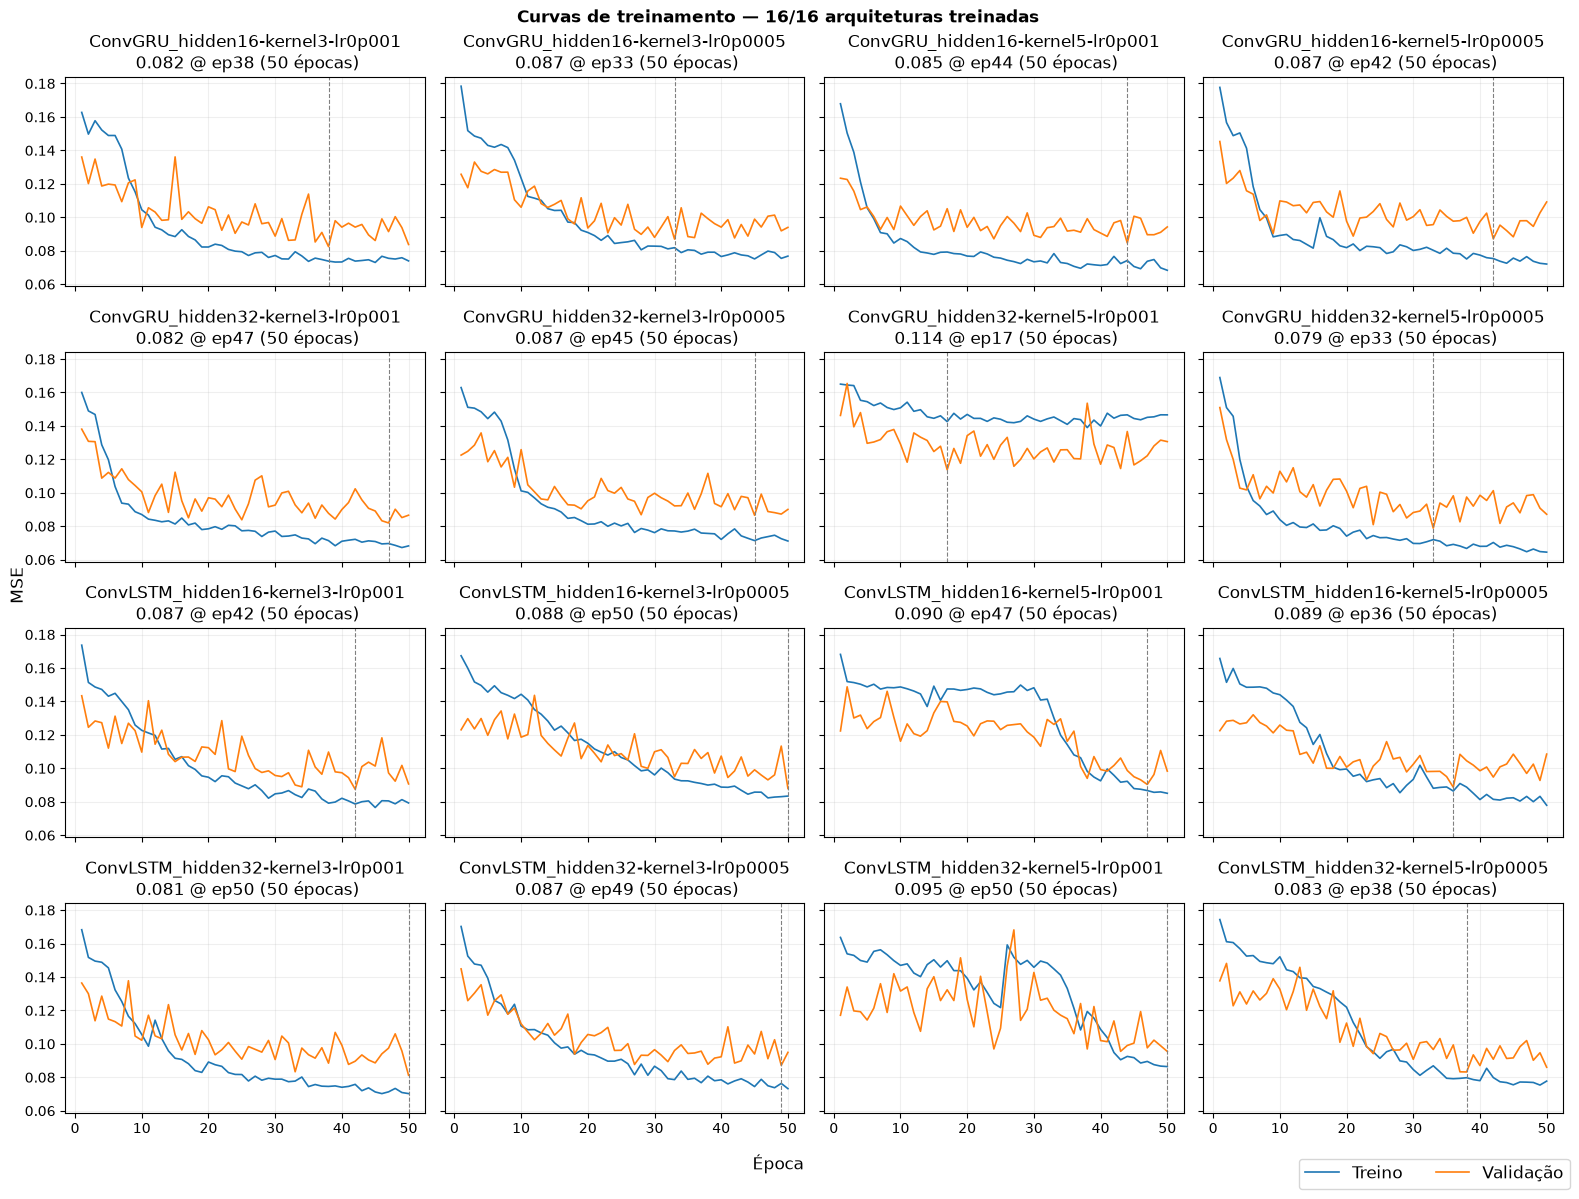

In [48]:
def plot_histories(ncols=4):
    
    runs = [
        f"{arch}_" + f"hidden{hidden}-" + f"kernel{kernel}-" + f"lr{lr}".replace(".", "p")
        for arch in ARCH
        for hidden in HIDDEN_CHANNELS
        for kernel in KERNEL_SIZE
        for lr in LEARNING_RATE
    ]
    
    nrows = -(-len(runs) // ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_1d(axes).ravel()
    
    trained = 0
    
    for ax, run in zip(axes, runs):
        history = load_history(run, LOGS_DIR)
        
        if history is None:
            ax.set_title(run, fontsize=12, color="grey")
            ax.text(
                0.5, 0.5, "not trained yet",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=9, color="grey"
            )
            continue
        
        trained += 1
        epochs = history["epoch"] + 1
        
        ax.plot(epochs, history["train_loss"], label="Treino", linewidth=1.2)
        ax.plot(epochs, history["val_loss"], label="Validação", linewidth=1.2)
        
        best = history["val_loss"].idxmin()
        best_epoch = int(history.loc[best, "epoch"]) + 1
        ax.axvline(best_epoch, linestyle="--", linewidth=0.8, color="grey")
        
        ax.set_title(
            f"{run}\n {history['val_loss'].min():.3f} @ ep{best_epoch}"
            f" ({len(history)} épocas)",
            fontsize=12
        )
        ax.grid(alpha=0.2)
    
    for ax in axes[len(runs):]:
        ax.axis("off")
    
    fig.supxlabel("Época")
    fig.supylabel("MSE")
    
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower right", ncol=2, bbox_to_anchor=(1, -0.01), fontsize=12)
    
    fig.suptitle(
        f"Curvas de treinamento — {trained}/{len(runs)} arquiteturas treinadas",
        fontweight="bold"
    )
    
    plt.tight_layout()
    plt.show()

plot_histories()

Comparação visual entre a área de treino (*sample*) e a área de teste (*held-out*): composição média no tempo (VV/VH) ao lado do respectivo raster de rótulos, para checar visualmente o alinhamento entre imagem e rótulo em cada área:

/tmp/ipykernel_99374/245327502.py:17: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  vv = src.read(1)
/tmp/ipykernel_99374/245327502.py:19: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  vh = src.read(1)
/tmp/ipykernel_99374/245327502.py:31: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  train_labels = src.read(1)
/tmp/ipykernel_99374/245327502.py:34: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  test_labels = src.read(1)


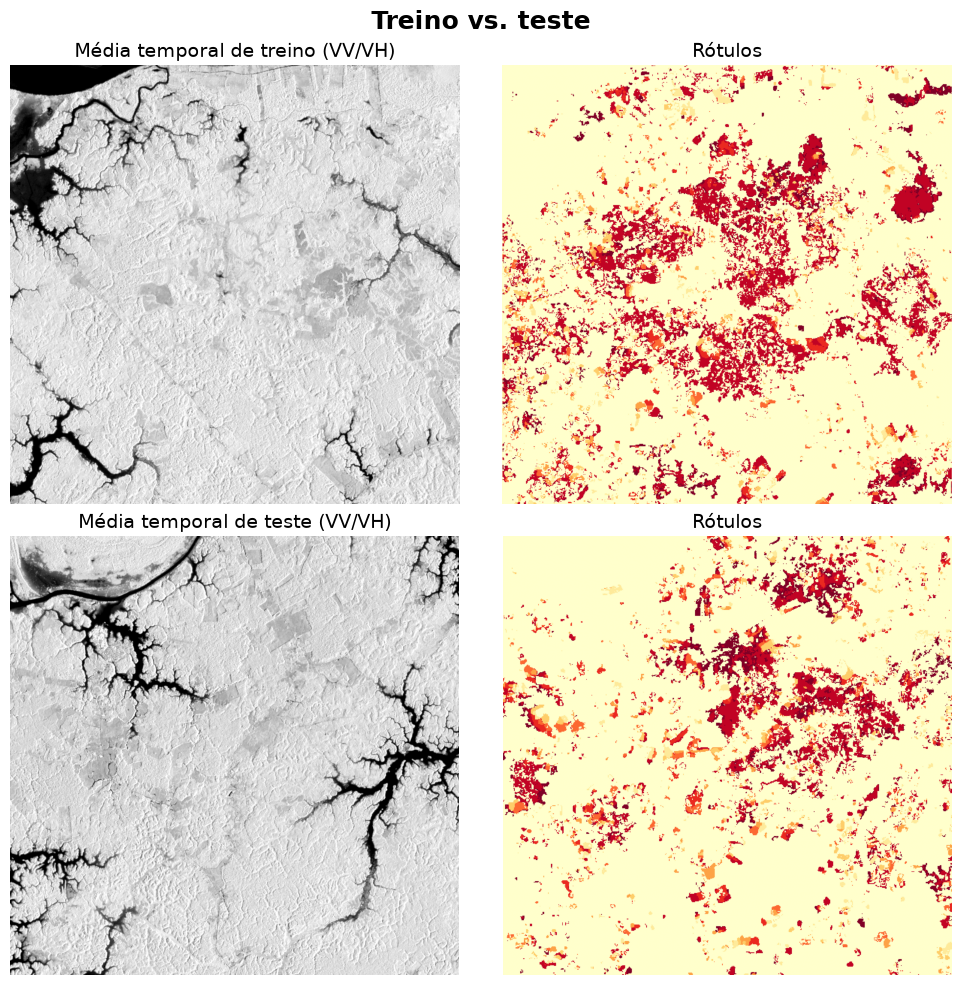

In [49]:
def time_mean(data_dir: str | Path) -> np.ndarray:

    data_dir = Path(data_dir)
    months = sorted({
        f.stem.split(".")[0]
        for f in data_dir.glob("*.tif")
    })

    with rio.open(data_dir / f"{months[0]}.VV.tif") as src:
        shape = (src.height, src.width)

    # Soma incremental por mês, para nunca ter a série completa em
    # memória de uma vez só
    acc = np.zeros(shape, dtype=np.float64)
    for month in months:
        with rio.open(data_dir / f"{month}.VV.tif") as src:
            vv = src.read(1)
        with rio.open(data_dir / f"{month}.VH.tif") as src:
            vh = src.read(1)
        acc += np.nan_to_num((vv + vh) / 2, nan=0.0)

    return (acc / len(months)).astype(np.float32)


def plot_data_overview():

    train_mean = time_mean(DATA_DIR)
    test_mean = time_mean(TEST_DATA_DIR)

    with rio.open(LABEL_PATH) as src:
        train_labels = src.read(1)

    with rio.open(TEST_LABEL_PATH) as src:
        test_labels = src.read(1)

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    fig.patch.set_alpha(0.0)

    panels = [
        (axes[0, 0], train_mean, "Média temporal de treino (VV/VH)", "gray", None),
        (axes[0, 1], train_labels, "Rótulos", "YlOrRd", (0, 1)),
        (axes[1, 0], test_mean, "Média temporal de teste (VV/VH)", "gray", None),
        (axes[1, 1], test_labels, "Rótulos", "YlOrRd", (0, 1)),
    ]

    for ax, arr, title, cmap, clim in panels:
        vmin, vmax = clim if clim is not None else np.nanpercentile(arr, [2, 98])
        ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=14)
        ax.axis("off")
        ax.patch.set_alpha(0.0)

    fig.suptitle("Treino vs. teste", fontweight="bold", fontsize=18)
    plt.tight_layout()
    plt.show()

plot_data_overview()

Predição do melhor modelo (`best_model.pth`, menor MAE na área de teste) sobre a área de treino, com e sem pós-processamento, ao lado dos rótulos:

/tmp/ipykernel_99374/2264220223.py:21: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  labels = src.read(1)


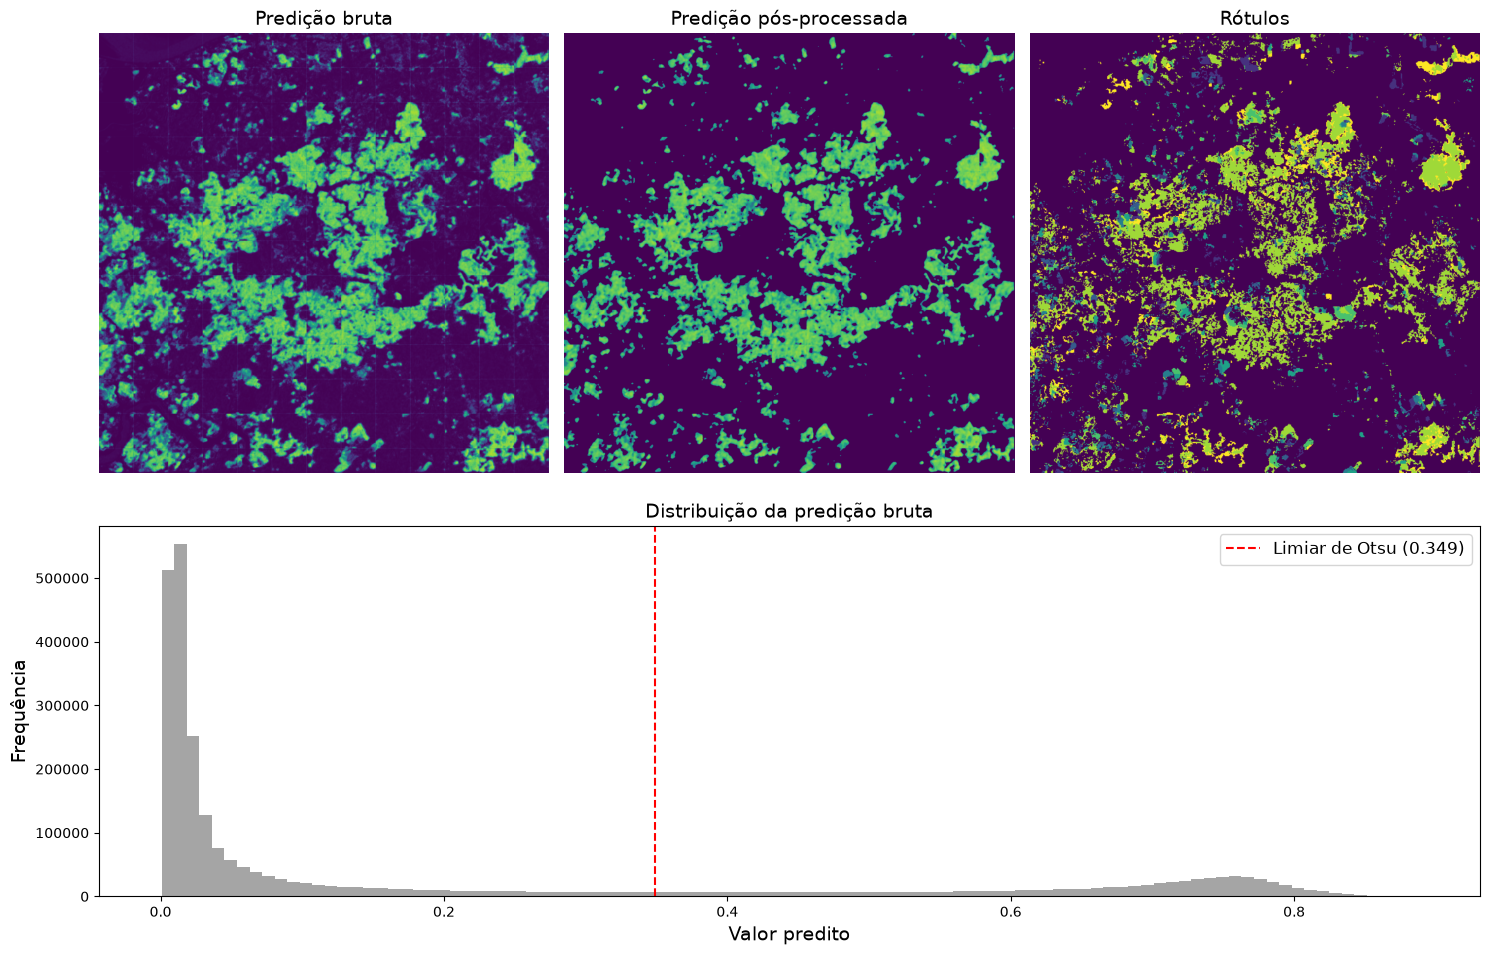

In [50]:
from skimage.filters import threshold_otsu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
arch = ConvGRURegressor if best_metrics["model"] == "ConvGRU" else ConvLSTMRegressor

model = load_weights(
    arch,
    best_model_path,
    device=device,
    input_channels=INPUT_CHANNELS,
    hidden_channels=int(best_metrics["hidden"]),
    kernel_size=int(best_metrics["kernel"]),
    head_channels=HEAD_CHANNELS
)

raw_pred = conv_rnn_predict(model, val_dataset, device, BATCH_SIZE, postproc=False)
post_pred = conv_rnn_predict(model, val_dataset, device, BATCH_SIZE, postproc=True)
threshold = threshold_otsu(raw_pred)

with rio.open(LABEL_PATH) as src:
    labels = src.read(1)

fig = plt.figure(figsize=(15, 10))
fig.patch.set_alpha(0.0)
gs = fig.add_gridspec(2, 3, height_ratios=[3, 2])

ax_raw = fig.add_subplot(gs[0, 0])
ax_post = fig.add_subplot(gs[0, 1])
ax_labels = fig.add_subplot(gs[0, 2])
ax_hist = fig.add_subplot(gs[1, :])

panels = [
    (ax_raw, raw_pred, "Predição bruta"),
    (ax_post, post_pred, "Predição pós-processada"),
    (ax_labels, labels, "Rótulos"),
]

for ax, arr, title in panels:
    ax.imshow(arr, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    ax.patch.set_alpha(0.0)

ax_hist.hist(raw_pred.ravel(), bins=100, color="grey", alpha=0.7)
ax_hist.axvline(threshold, color="red", linestyle="--", linewidth=1.5, label=f"Limiar de Otsu ({threshold:.3f})")
ax_hist.set_title("Distribuição da predição bruta", fontsize=14)
ax_hist.set_xlabel("Valor predito", fontsize=14)
ax_hist.set_ylabel("Frequência", fontsize=14)
ax_hist.legend(fontsize=12)
ax_hist.patch.set_alpha(0.0)
plt.tight_layout()
plt.show()

Melhor configuração por arquitetura (menor MAE) na área de teste, com a melhor configuração geral destacada:

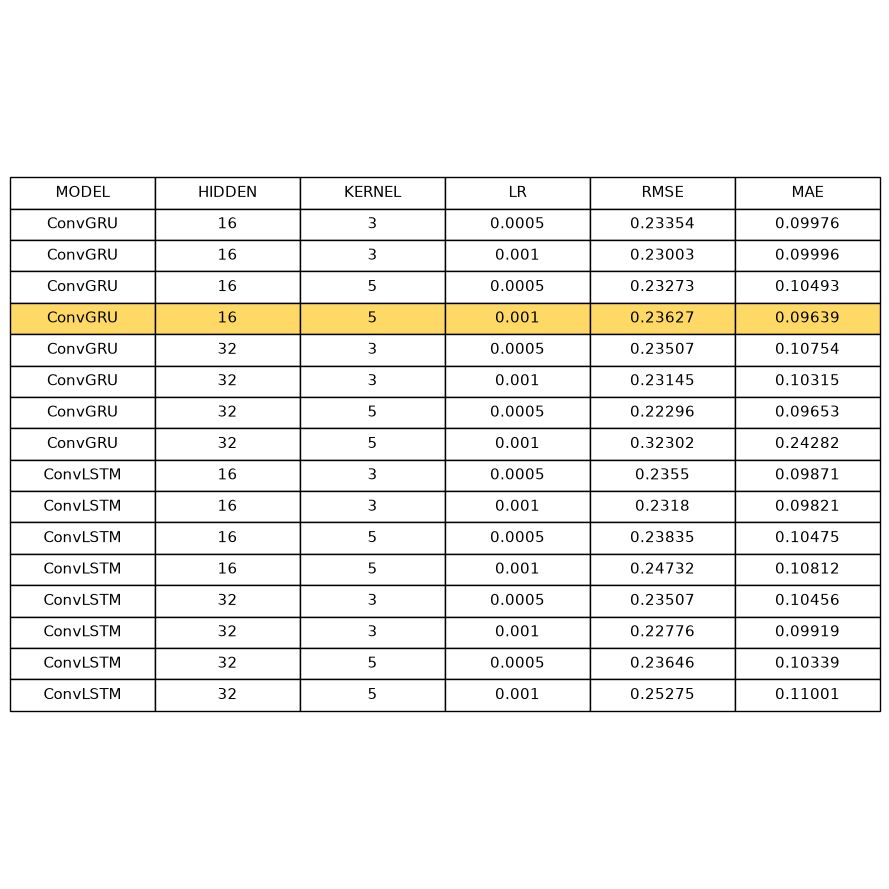

In [51]:
test_files = sorted(TEST_RESULTS_DIR.glob("*.parquet"))
test_summary = pd.concat([pd.read_parquet(f) for f in test_files], ignore_index=True)

columns = ["model", "hidden", "kernel", "lr", "rmse", "mae"]
table_df = test_summary[columns].reset_index(drop=True).round(5)
best_overall = table_df.loc[table_df["mae"].idxmin()]

fig, ax = plt.subplots(figsize=(9, 1 + 0.5 * len(table_df)))
fig.patch.set_alpha(0.0)
ax.axis("off")

tbl = ax.table(
    cellText=table_df.values,
    colLabels=[c.upper() for c in columns],
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.5)

best_row = table_df["mae"].idxmin()
for col in range(len(columns)):
    tbl[best_row + 1, col].set_facecolor("#ffd966")

plt.tight_layout()
plt.show()

Predição do melhor modelo (menor MAE) vs. rótulos, nas áreas de treino e teste — usando os rasters já salvos por `evaluate()`, sem reexecutar inferência:

/tmp/ipykernel_99374/2803728974.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  train_labels = src.read(1)
/tmp/ipykernel_99374/2803728974.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  test_labels = src.read(1)
/tmp/ipykernel_99374/2803728974.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  train_pred = src.read(1)
/tmp/ipykernel_99374/2803728974.py:16: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  test_pred = src.read(1)


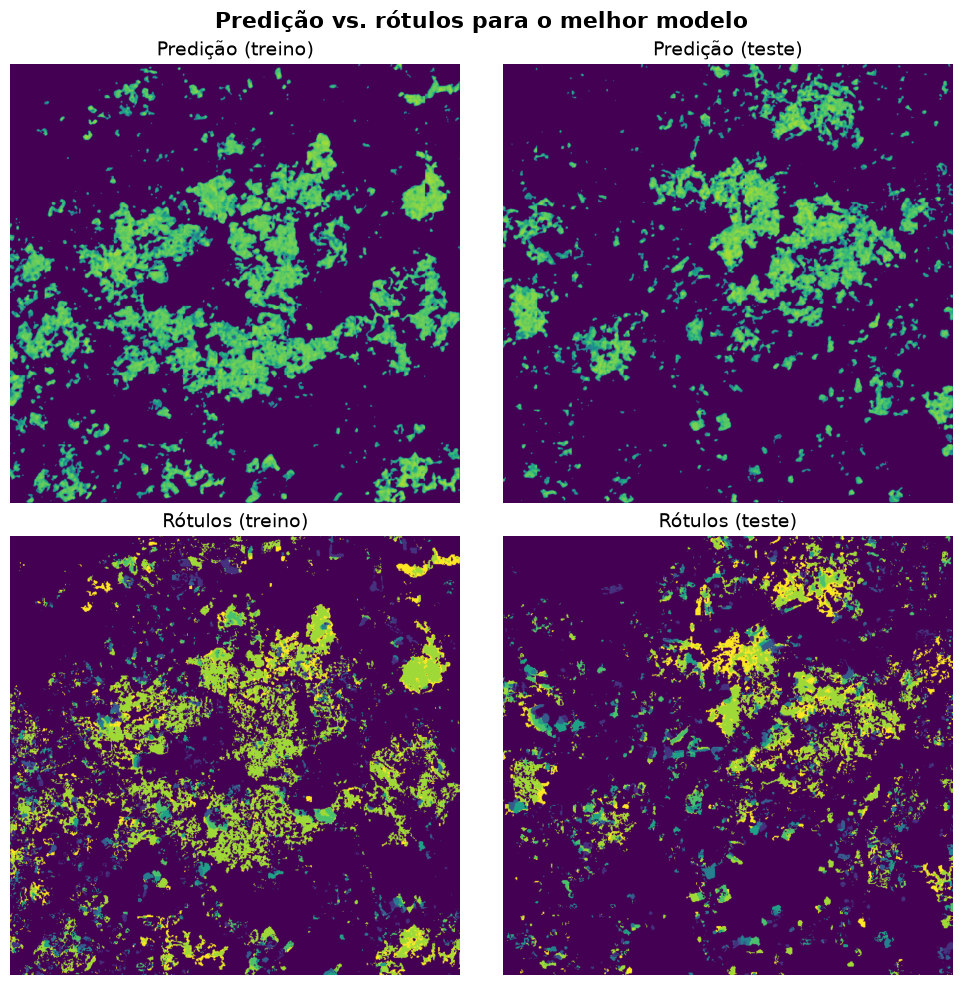

In [32]:
best_run = (
    f"{best_overall['model']}_hidden{int(best_overall['hidden'])}"
    f"-kernel{int(best_overall['kernel'])}-lr{best_overall['lr']}"
).replace(".", "p")

with rio.open(LABEL_PATH) as src:
    train_labels = src.read(1)

with rio.open(TEST_LABEL_PATH) as src:
    test_labels = src.read(1)

with rio.open(VAL_RESULTS_DIR / f"{best_run}.tif") as src:
    train_pred = src.read(1)

with rio.open(TEST_RESULTS_DIR / f"{best_run}.tif") as src:
    test_pred = src.read(1)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.patch.set_alpha(0.0)

panels = [
    (axes[0, 0], train_pred, "Predição (treino)"),
    (axes[0, 1], test_pred, "Predição (teste)"),
    (axes[1, 0], train_labels, "Rótulos (treino)"),
    (axes[1, 1], test_labels, "Rótulos (teste)"),
]

for ax, arr, title in panels:
    ax.imshow(arr, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    ax.patch.set_alpha(0.0)

fig.suptitle(f"Predição vs. rótulos para o melhor modelo", fontweight="bold", fontsize=16)
plt.tight_layout()
plt.show()